### Loading and Cleaning the Data

- Importing libraries and dependencies

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

- Loading Datasets

In [2]:
# Load all datasets
orders_df = pd.read_csv('../data/raw/orders.csv')
order_products_prior_df = pd.read_csv('../data/raw/order_products__prior.csv')
order_products_train_df = pd.read_csv('../data/raw/order_products__train.csv')
products_df = pd.read_csv('../data/raw/products.csv')
aisles_df = pd.read_csv('../data/raw/aisles.csv')
departments_df = pd.read_csv('../data/raw/departments.csv')

# Pandas Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)


- Quick look at the Datasets

In [3]:
datasets = {
    'orders': orders_df,
    'order_products_prior': order_products_prior_df,
    'order_products_train': order_products_train_df,
    'products': products_df,
    'aisles': aisles_df
}

for name, df in datasets.items():
    print(f"\n{'='*40}")
    print(f"{name}: {df.shape[0]:,} rows x {df.shape[1]} cols")
    print(df.dtypes)
    print(f"Nulls:\n{df.isnull().sum()}")


orders: 3,421,083 rows x 7 cols
order_id                    int64
user_id                     int64
eval_set                   object
order_number                int64
order_dow                   int64
order_hour_of_day           int64
days_since_prior_order    float64
dtype: object
Nulls:
order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

order_products_prior: 32,434,489 rows x 4 cols
order_id             int64
product_id           int64
add_to_cart_order    int64
reordered            int64
dtype: object
Nulls:
order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64

order_products_train: 1,384,617 rows x 4 cols
order_id             int64
product_id           int64
add_to_cart_order    int64
reordered            int64
dtype: object
Nulls:
order_

- Handling missing values: 

We have 206209 missing days_since_prior_order values in the orders dataframe, we can assume they are empty since the customer hasn't had any previous orders or we don't have data from any previous orders. So I will replace these values with 0. 

In [4]:
# Fill nulls in days_since_prior_order 
orders_df['days_since_prior_order'] = orders_df['days_since_prior_order'].fillna(0)

- How the data is divided

The Dataset has already been divided to prior, which is every customers prior order data and training which would be there most recent order. So using the prior data we will be trying to predict their most recent order.

In [5]:
print(f"\nUnique users: {orders_df['user_id'].nunique():,}")
print(f"Unique orders: {orders_df['order_id'].nunique():,}")
print(f"\nEval set distribution:\n{orders_df['eval_set'].value_counts()}")


Unique users: 206,209
Unique orders: 3,421,083

Eval set distribution:
eval_set
prior    3214874
train     131209
test       75000
Name: count, dtype: int64


- Merging all dfs together

In [6]:
# Merge order_products_prior with orders
prior = order_products_prior_df.merge(orders_df, on='order_id', how='left')

# Merge with product names, aisles, departments
prior = prior.merge(products_df, on='product_id', how='left')
prior = prior.merge(aisles_df, on='aisle_id', how='left')
prior = prior.merge(departments_df, on='department_id', how='left')

print(f"Master dataframe shape: {prior.shape}")
print(f"\nColumns: {prior.columns.tolist()}")
prior.head()

Master dataframe shape: (32434489, 15)

Columns: ['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order', 'product_name', 'aisle_id', 'department_id', 'aisle', 'department']


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,prior,3,5,9,8.00,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,prior,3,5,9,8.00,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,prior,3,5,9,8.00,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,202279,prior,3,5,9,8.00,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,202279,prior,3,5,9,8.00,Natural Sweetener,17,13,baking ingredients,pantry


Looking at any patterns in number of orders by dow or hour 

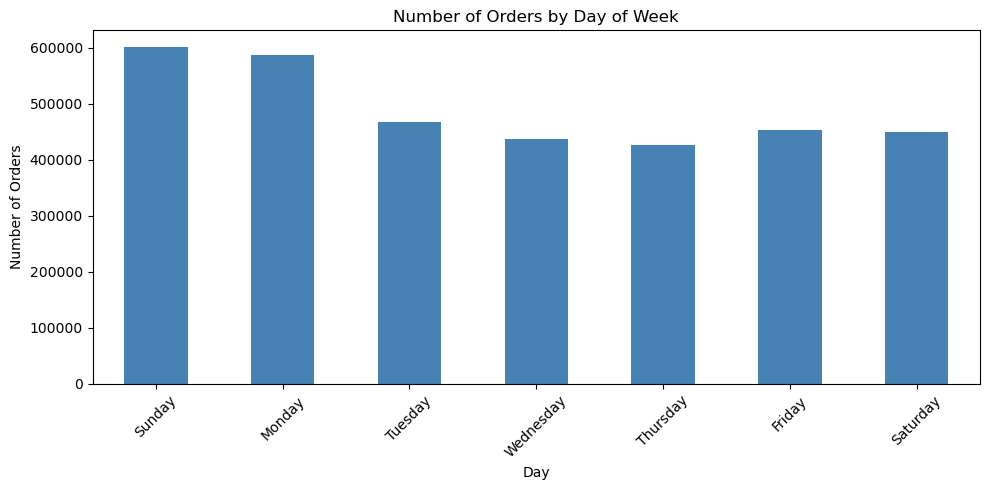

In [7]:
plt.figure(figsize=(10, 5))
day_map = {0: 'Sunday', 1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 
           4: 'Thursday', 5: 'Friday', 6: 'Saturday'}
orders_df['order_dow'].map(day_map).value_counts().reindex(day_map.values()).plot(kind='bar', color='steelblue')
plt.title('Number of Orders by Day of Week')
plt.xlabel('Day')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

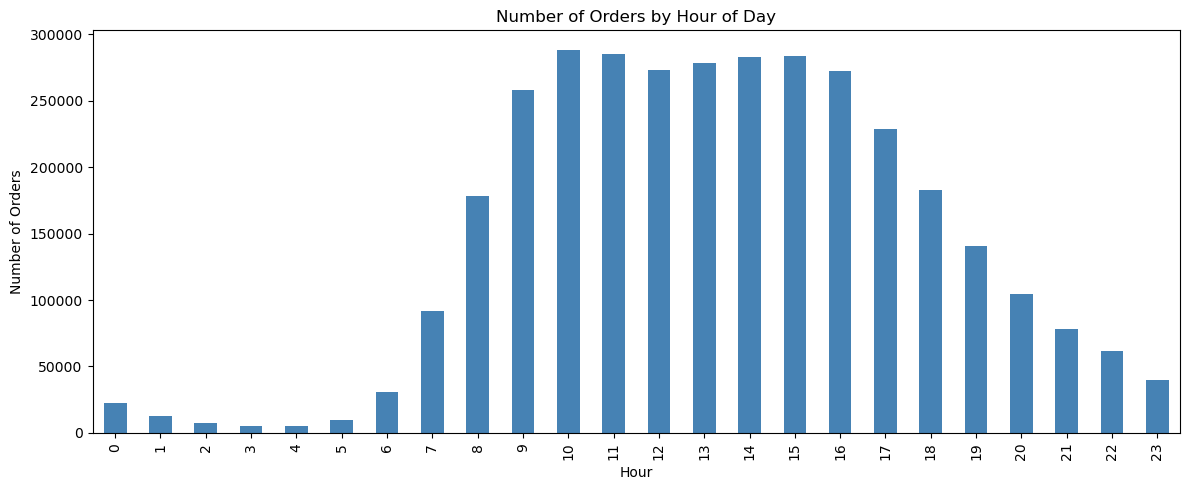

In [8]:
plt.figure(figsize=(12, 5))
orders_df['order_hour_of_day'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Number of Orders by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

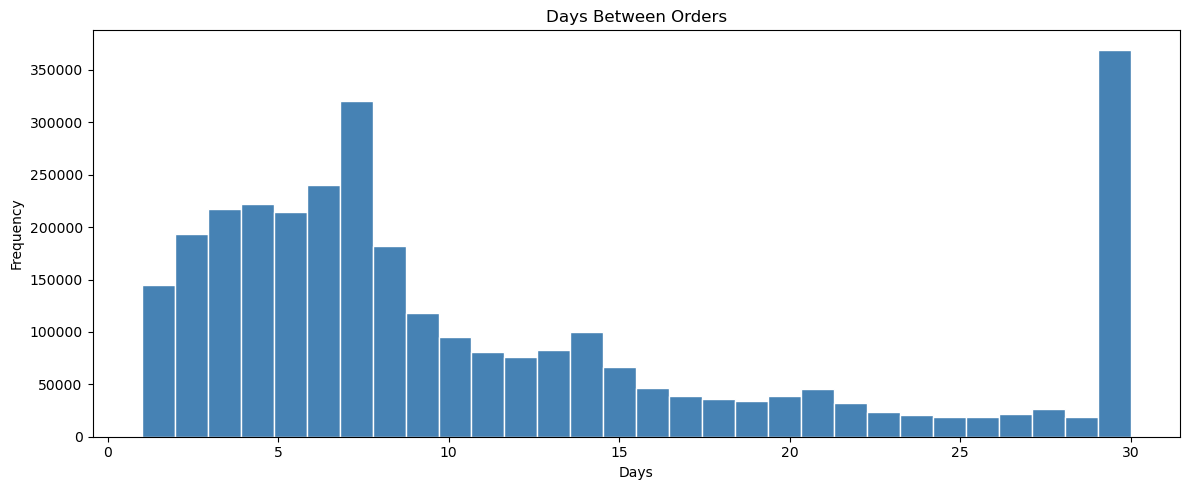

In [10]:
plt.figure(figsize=(12, 5))
orders_df[orders_df['days_since_prior_order'] > 0]['days_since_prior_order'].plot(
    kind='hist', bins=30, color='steelblue', edgecolor='white')
plt.title('Days Between Orders')
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

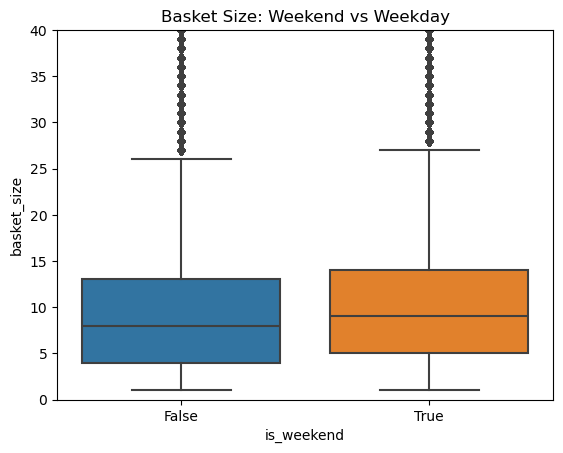

In [16]:
#### Temporal ####
# the data never documents which day 0 is. days 0 and 1 have way more
# orders than the rest, so they're almost certainly the weekend. treating 0,1 as weekend.
order_level['is_weekend'] = order_level['order_dow'].isin([0, 1])

sns.boxplot(x='is_weekend', y='basket_size', data=order_level)
plt.title('Basket Size: Weekend vs Weekday')
plt.ylim(0, 40)
plt.show()

In [17]:
# what sells MORE on weekends?
prior['is_weekend'] = prior['order_dow'].isin([0, 1])
mix = prior.groupby('is_weekend')['department'].value_counts(normalize=True).unstack(0)
mix.columns = ['weekday_share', 'weekend_share']
mix['weekend_lift'] = mix['weekend_share'] / mix['weekday_share']
mix.sort_values('weekend_lift', ascending=False).head(10)
# lift > 1 = that department is relatively more popular on weekends

,weekday_share,weekend_share,weekend_lift
department,,,
produce,0.28,0.31,1.08
canned goods,0.03,0.03,1.07
meat seafood,0.02,0.02,1.07
dry goods pasta,0.03,0.03,1.06
international,0.01,0.01,1.06
deli,0.03,0.03,1.04
dairy eggs,0.17,0.17,1.00
bakery,0.04,0.04,1.00
babies,0.01,0.01,1.00


## Product Level Analysis

/Users/farxane/miniconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


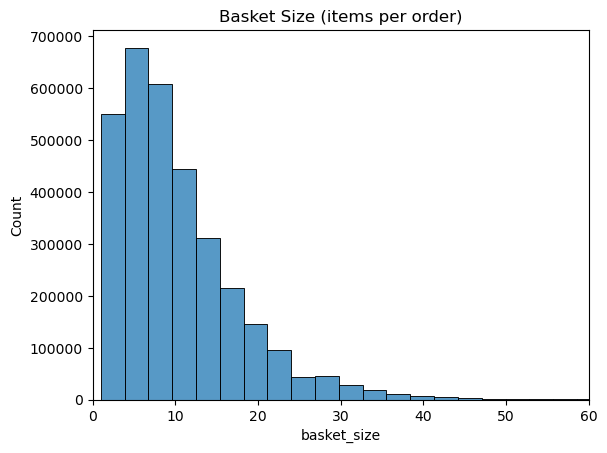

count   3214874.00
mean         10.09
std           7.53
min           1.00
25%           5.00
50%           8.00
75%          14.00
max         145.00
Name: basket_size, dtype: float64

In [11]:
# typical basket size
order_level = prior.groupby('order_id').agg(
    basket_size=('product_id', 'size'),
    order_dow=('order_dow', 'first'),
    order_hour_of_day=('order_hour_of_day', 'first')
).reset_index()

sns.histplot(order_level['basket_size'], bins=50)
plt.title('Basket Size (items per order)')
plt.xlim(0, 60)
plt.show()
order_level['basket_size'].describe()

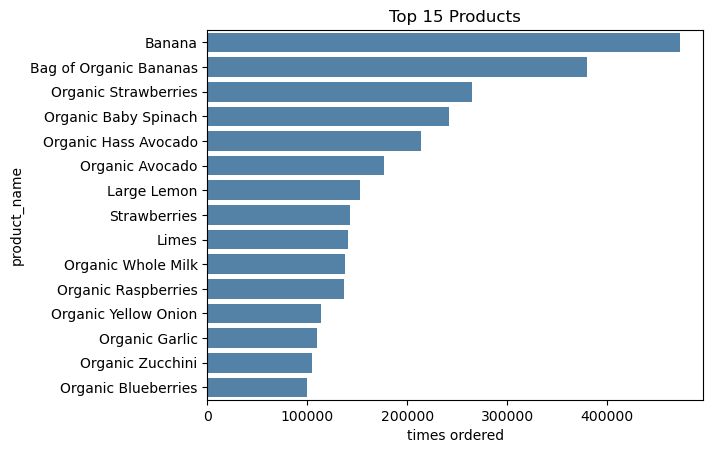

In [12]:
# what are people actually buying most?
top_products = prior['product_name'].value_counts().head(15)
sns.barplot(x=top_products.values, y=top_products.index, color='steelblue')
plt.title('Top 15 Products')
plt.xlabel('times ordered')
plt.show()

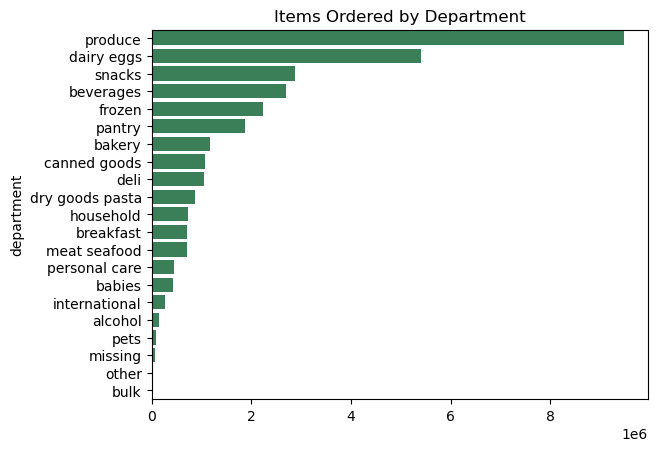

In [13]:
#department sales
top_depts = prior['department'].value_counts()
sns.barplot(x=top_depts.values, y=top_depts.index, color='seagreen')
plt.title('Items Ordered by Department')
plt.show()

## Reorder Behaviour Analysis

reordered
1   0.59
0   0.41
Name: proportion, dtype: float64


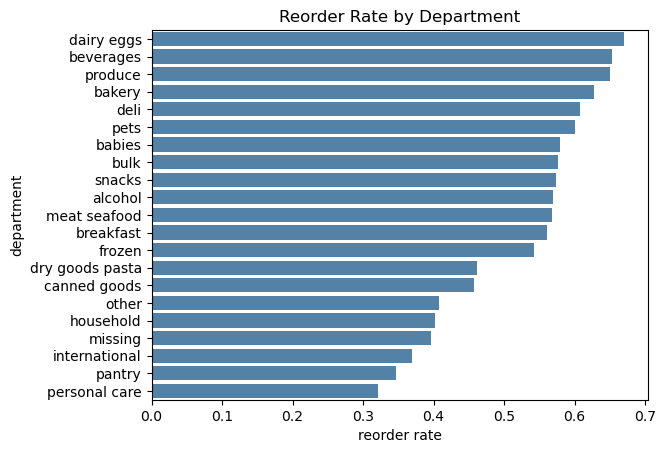

In [14]:
#### Reorder Behavior ####
# overall, what share of items bought are reorders vs new? (1=reorder, 0=first time)
print(prior['reordered'].value_counts(normalize=True))

# reorder rate by department — habitual categories vs exploratory ones
dept_reorder = prior.groupby('department')['reordered'].mean().sort_values(ascending=False)
sns.barplot(x=dept_reorder.values, y=dept_reorder.index, color='steelblue')
plt.title('Reorder Rate by Department')
plt.xlabel('reorder rate')
plt.show()
# dairy/produce/beverages should be high (staples); pantry/personal care lower

In [15]:
# which specific products are most habitually reordered?
# require a min order count so 1-off flukes dont top the list
product_reorder = prior.groupby('product_name').agg(
    times_ordered=('reordered', 'size'),
    reorder_rate=('reordered', 'mean')
)
product_reorder = product_reorder[product_reorder['times_ordered'] > 40]
product_reorder.sort_values('reorder_rate', ascending=False).head(15)

,times_ordered,reorder_rate
product_name,,
Raw Veggie Wrappers,68,0.94
Serenity Ultimate Extrema Overnight Pads,87,0.93
Chocolate Love Bar,101,0.92
Simply Sleep Nighttime Sleep Aid,45,0.91
Sparking Water,60,0.90
Maca Buttercups,100,0.90
Bars Peanut Butter,67,0.90
Soy Crisps Lightly Salted,66,0.89
Benchbreak Chardonnay,111,0.89


## Customer Level Analysis

/Users/farxane/miniconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


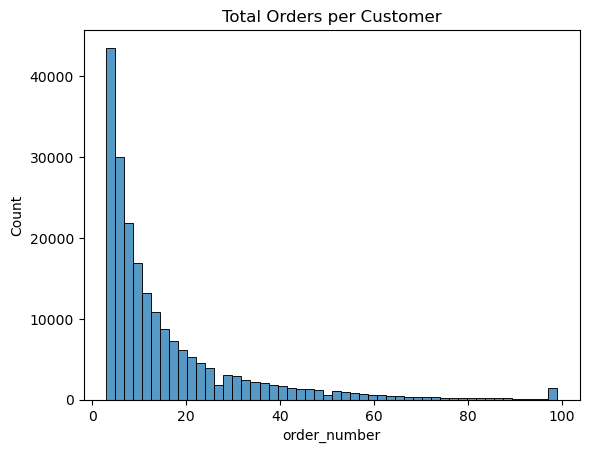

count   206209.00
mean        15.59
std         16.65
min          3.00
25%          5.00
50%          9.00
75%         19.00
max         99.00
Name: order_number, dtype: float64

In [ ]:
prior_orders = orders_df[orders_df['eval_set'] == 'prior'].copy()

# how many orders per customer? (frequency)
orders_per_user = prior_orders.groupby('user_id')['order_number'].max()
sns.histplot(orders_per_user, bins=50)
plt.title('Total Orders per Customer')
plt.show()
orders_per_user.describe()

##### RFM Segmentation

In [19]:
#### RFM (adapted for instacart) ####
# classic RFM = Recency / Frequency / Monetary. instacart has no prices, so we adapt:
#   Recency   = days_since_prior_order on their most recent order (proxy, no real dates)
#   Frequency = total orders
#   Monetary  = total items ever bought (our stand-in for spend)

frequency = prior_orders.groupby('user_id')['order_number'].max().rename('frequency')
last_orders = prior_orders.sort_values('order_number').groupby('user_id').tail(1)
recency = last_orders.set_index('user_id')['days_since_prior_order'].rename('recency')
monetary = prior.groupby('user_id').size().rename('monetary')

rfm = pd.concat([frequency, recency, monetary], axis=1).reset_index()

# score each 1-5. recency is reversed (more recent = higher score).
# .rank(method='first') avoids qcut errors when there are lots of tied values
rfm['R_score'] = pd.qcut(rfm['recency'].rank(method='first'), 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_sum'] = rfm[['R_score','F_score','M_score']].sum(axis=1)
rfm.head()

,user_id,frequency,recency,monetary,R_score,F_score,M_score,RFM_sum
0,1,10,30.00,59,2,3,2,7
1,2,14,13.00,195,3,4,4,11
2,3,12,15.00,88,3,3,3,9
3,4,5,0.00,18,5,2,1,8
4,5,4,19.00,37,3,1,2,6


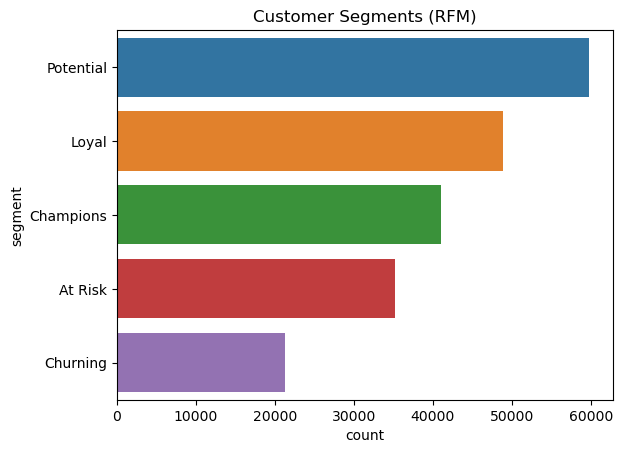

segment
Potential    59823
Loyal        48821
Champions    41023
At Risk      35218
Churning     21324
Name: count, dtype: int64

In [20]:
# turn the scores into human-readable segments
def segment(s):
    if s >= 13: return 'Champions'
    elif s >= 10: return 'Loyal'
    elif s >= 7: return 'Potential'
    elif s >= 5: return 'At Risk'
    else: return 'Churning'

rfm['segment'] = rfm['RFM_sum'].apply(segment)
sns.countplot(y='segment', data=rfm, order=rfm['segment'].value_counts().index)
plt.title('Customer Segments (RFM)')
plt.show()
rfm['segment'].value_counts()

### ABC Analysis

In [21]:
# rank products by volume, classify by cumulative contribution (classic pareto)
prod_volume = prior['product_name'].value_counts().reset_index()
prod_volume.columns = ['product_name', 'volume']
prod_volume['cum_pct'] = prod_volume['volume'].cumsum() / prod_volume['volume'].sum()

def abc_class(p):
    if p <= 0.80: return 'A'      # top products making up 80% of volume
    elif p <= 0.95: return 'B'    # next 15%
    else: return 'C'              # the long tail

prod_volume['ABC'] = prod_volume['cum_pct'].apply(abc_class)
prod_volume['ABC'].value_counts()

ABC
C    34860
B    10280
A     4537
Name: count, dtype: int64

In [22]:
# the payoff: see how concentrated demand really is
abc_summary = prod_volume.groupby('ABC').agg(
    n_products=('product_name', 'count'),
    total_volume=('volume', 'sum')
)
abc_summary['pct_of_products'] = abc_summary['n_products'] / abc_summary['n_products'].sum()
abc_summary['pct_of_volume'] = abc_summary['total_volume'] / abc_summary['total_volume'].sum()
abc_summary
# you'll see a small % of products drives most of the volume — that's the A class

,n_products,total_volume,pct_of_products,pct_of_volume
ABC,,,,
A,4537,25946539,0.09,0.80
B,10280,4866065,0.21,0.15
C,34860,1621885,0.70,0.05


### XYZ Analysis

In [23]:
# predictability via coefficient of variation (std/mean) of demand.
# no real weeks in this data, so day-of-week is our time axis (honest proxy).
# low CV = steady/predictable (X), high CV = erratic (Z)
dow_demand = prior.groupby(['product_name', 'order_dow']).size().unstack(fill_value=0)
cv = (dow_demand.std(axis=1) / dow_demand.mean(axis=1)).rename('cv')

def xyz_class(c):
    if c <= 0.5: return 'X'
    elif c <= 1.0: return 'Y'
    else: return 'Z'

xyz = cv.to_frame()
xyz['XYZ'] = xyz['cv'].apply(xyz_class)
xyz = xyz.reset_index()
xyz['XYZ'].value_counts()

XYZ
X    30765
Y    13691
Z     5221
Name: count, dtype: int64

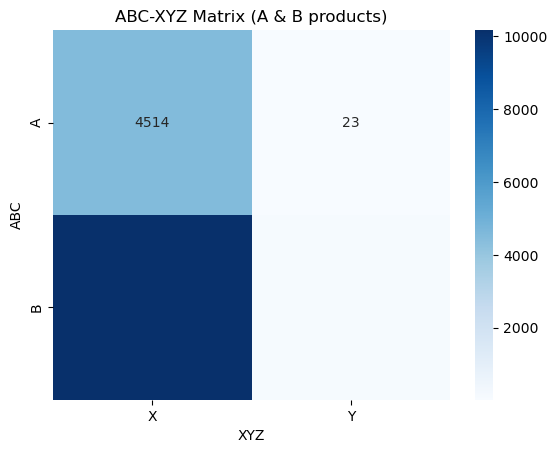

XYZ,X,Y
ABC,,
A,4514,23
B,10167,113


In [24]:
#### ABC-XYZ Matrix ####
matrix = prod_volume.merge(xyz, on='product_name', how='left')

# the long C tail is erratic by nature (low volume = noisy CV), so focus the
# matrix on A & B products — the ones actually worth managing
focus = matrix[matrix['ABC'].isin(['A', 'B'])]

cross = pd.crosstab(focus['ABC'], focus['XYZ'])
sns.heatmap(cross, annot=True, fmt='d', cmap='Blues')
plt.title('ABC-XYZ Matrix (A & B products)')
plt.show()
cross

AX — high volume, predictable demand → your never-run-out staples. Forecasting these is easy and high-payoff.

AZ — high volume but erratic → important but hard to forecast, the ones that cause stockouts and need safety stock.

BX / BY — solid mid-tier, manage normally.

CZ (in the full matrix, not the focused view) — low volume and erratic → delisting / clearance candidates.

## Churn Prediction

Instacart has no explicit "this customer left" label

We define churn relative to each customer's own rhythm — a customer is "at risk" if their next order took more than 1.5× their personal average gap to arrive. This matters because a 20-day gap is normal for an infrequent shopper but alarming for someone who usually orders weekly. Controlling for personal cadence is more honest than a flat "didn't order in 30 days" threshold.
The leakage-safe part: the label comes from the future order (the train eval_set), and every feature comes only from prior history. We never let the model peek at the thing it's predicting.

### Build Features from prior history

In [25]:
prior_orders = orders_df[orders_df['eval_set'] == 'prior'].sort_values(
    ['user_id', 'order_number']).copy()

# cadence stats (exclude the first-order 0s — they aren't real gaps)
gaps = prior_orders[prior_orders['days_since_prior_order'] > 0]
gap_stats = gaps.groupby('user_id')['days_since_prior_order'].agg(
    avg_gap='mean', std_gap='std')

# order count + recency
user_feats = prior_orders.groupby('user_id').agg(
    frequency=('order_number', 'max'),
    last_gap=('days_since_prior_order', 'last'))

# product behaviour from the merged prior df
prod_feats = prior.groupby('user_id').agg(
    total_items=('product_id', 'size'),
    reorder_rate=('reordered', 'mean'),
    n_unique_products=('product_id', 'nunique'))
prod_feats['avg_basket'] = prod_feats['total_items'] / user_feats['frequency']

features = user_feats.join(gap_stats).join(prod_feats)
features['std_gap'] = features['std_gap'].fillna(0)  # 1-gap users have no std
features.head()

,frequency,last_gap,avg_gap,std_gap,total_items,reorder_rate,n_unique_products,avg_basket
user_id,,,,,,,,
1,10,30.00,22.00,6.28,59,0.69,18,5.90
2,14,13.00,15.23,9.87,195,0.48,102,13.93
3,12,15.00,12.09,5.38,88,0.62,33,7.33
4,5,0.00,18.33,3.06,18,0.06,17,3.60
5,4,19.00,13.33,4.93,37,0.38,23,9.25


### Attaching Label from future order

In [32]:
train_orders = orders_df[orders_df['eval_set'] == 'train'][['user_id', 'days_since_prior_order']]
train_orders = train_orders.rename(columns={'days_since_prior_order': 'next_gap'})

df = features.join(train_orders.set_index('user_id'), how='inner')
df = df.dropna(subset=['avg_gap'])   # need a personal average to compare against

# REVISED churn definition — independent of any feature.
# churn = hit the 30-day cap = a full month+ without reordering.
df['churn'] = (df['next_gap'] >= 30).astype(int)
df['churn'].value_counts(normalize=True)

churn
0   0.69
1   0.31
Name: proportion, dtype: float64

## Train and compare models

In [33]:
feature_cols = ['frequency', 'last_gap', 'avg_gap', 'std_gap',
                'total_items', 'reorder_rate', 'n_unique_products', 'avg_basket']
X, y = df[feature_cols], df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [34]:
# baseline: logistic regression
logreg = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg.fit(X_train_s, y_train)
print("Logistic Regression")
print(classification_report(y_test, logreg.predict(X_test_s)))

Logistic Regression
              precision    recall  f1-score   support

           0       0.85      0.64      0.73     18216
           1       0.48      0.74      0.58      8023

    accuracy                           0.67     26239
   macro avg       0.66      0.69      0.66     26239
weighted avg       0.74      0.67      0.69     26239



In [35]:
# random forest — usually stronger on tabular data
rf = RandomForestClassifier(n_estimators=200, max_depth=12,
                            class_weight='balanced', n_jobs=-1, random_state=1)
rf.fit(X_train_s, y_train)
print("Random Forest")
print(classification_report(y_test, rf.predict(X_test_s)))

Random Forest
              precision    recall  f1-score   support

           0       0.85      0.66      0.74     18216
           1       0.49      0.73      0.58      8023

    accuracy                           0.68     26239
   macro avg       0.67      0.70      0.66     26239
weighted avg       0.74      0.68      0.70     26239



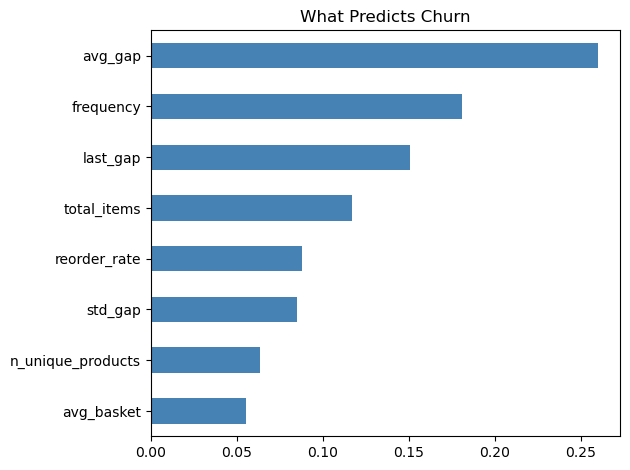

In [36]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
importances.plot(kind='barh', color='steelblue')
plt.title('What Predicts Churn')
plt.tight_layout()
plt.show()

ROC-AUC: 0.764
PR-AUC : 0.548


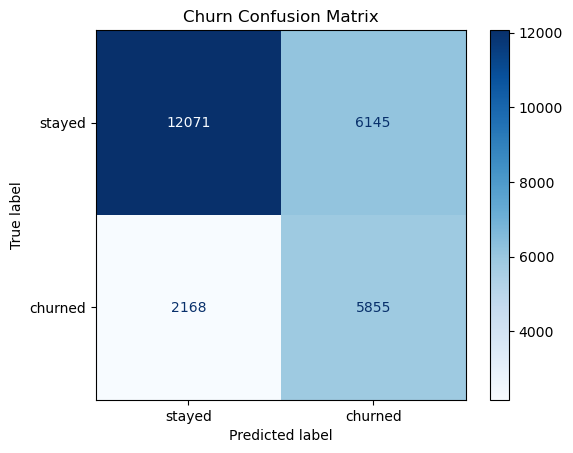

In [37]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, average_precision_score)

rf_probs = rf.predict_proba(X_test_s)[:, 1]
print("ROC-AUC:", round(roc_auc_score(y_test, rf_probs), 3))
print("PR-AUC :", round(average_precision_score(y_test, rf_probs), 3))

cm = confusion_matrix(y_test, rf.predict(X_test_s))
ConfusionMatrixDisplay(cm, display_labels=['stayed', 'churned']).plot(cmap='Blues')
plt.title('Churn Confusion Matrix')
plt.show()

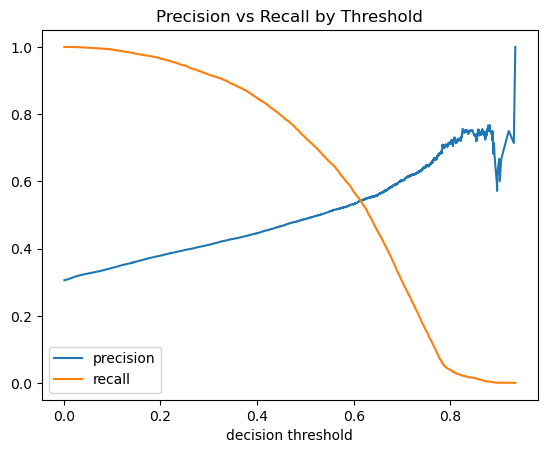

In [38]:
from sklearn.metrics import precision_recall_curve
prec, rec, thresh = precision_recall_curve(y_test, rf_probs)
plt.plot(thresh, prec[:-1], label='precision')
plt.plot(thresh, rec[:-1], label='recall')
plt.xlabel('decision threshold'); plt.legend()
plt.title('Precision vs Recall by Threshold')
plt.show()
# push the threshold above 0.5 to buy precision at the cost of recall